# Heart Disease EDA

Goals:
- understand the dataset structure
- study the target variable
- check missing values and duplicates
- explore numerical and categorical features
- write medical and business insights


## 1. Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

#Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

## 2. Load Dataset

**Dataset Source:** https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data 

**Task:** Binary Classification - Predict heart disease presence

In [38]:
n_dir = Path.cwd()
data_path = n_dir.parent/'data'/ 'raw' /'heart_disease_uci.csv'
print(f"Load from: {data_path}")

#load dataset
df = pd.read_csv(data_path)
df.head()

Load from: D:\Sutathip003.github.io\Projects\Heart disease project\data\raw\heart_disease_uci.csv


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3.Check dataset structure

In [43]:
# check columns
print(f"Data shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nData columns: \n{df.columns.tolist()}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Data shape: 920 rows x 16 columns

Data columns: 
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Memory usage: 0.40 MB


### Feature Dictionary
- **id**: Patient identifier
- **age**: Patient age (years)
- **sex**: 1=male, 0=female
- **dataset**: Data collection location
- **cp**: Chest pain type (0-3, ordered by severity)
- **trestbps**: Resting blood pressure (mmHg)
- **chol**: Serum cholesterol (mg/dL)
- **fbs**: Fasting blood sugar > 120 mg/dL
- **restecg**: ECG at rest
- **thalach**: Maximum heart rate achieved
- **exang**: Exercise-induced angina
- **oldpeak**: ST depression (ECG change)
- **slope**: ST segment slope
- **ca**: Number of major vessels (0-3)
- **thal**: Thalassemia
- **num**: TARGET - Heart disease (0=no, 1-4=yes, levels of severity)

In [30]:
# check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [37]:
# classiffy columns
categorical_cols = []
numerical_cols = []

for col in df.columns:
    if df[col].dtype == 'object':
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)
        
print(f"Numerical colums: {numerical_cols}")
print(f"Categorical colums: {categorical_cols}") 

Numerical colums: ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']
Categorical colums: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


## 4.Check data quality

In [48]:
#Check missing values
missing_values = df.isnull().sum()
missing_ratio = (df.isnull().mean()*100).round(2)

missing_df = pd.DataFrame({
    'missing count' : missing_values,
    'missing ratio (%)' : missing_ratio   
})
print(missing_df.sort_values(by='missing ratio (%)', ascending=False))

          missing count  missing ratio (%)
ca                  611              66.41
thal                486              52.83
slope               309              33.59
fbs                  90               9.78
oldpeak              62               6.74
trestbps             59               6.41
thalch               55               5.98
exang                55               5.98
chol                 30               3.26
restecg               2               0.22
id                    0               0.00
age                   0               0.00
sex                   0               0.00
dataset               0               0.00
cp                    0               0.00
num                   0               0.00


### EDA Notes

- The columns with the most missing values are `ca` (**611 missing**), `thal` (**486 missing**), and `slope` (**309 missing**). These gaps are large enough to affect model reliability if handled poorly.
- Moderate missingness also exists in `fbs` (90), `oldpeak` (62), `trestbps` (59), `exang` (55), `thalch` (55), and `chol` (30). Only `restecg` has very little missing data.
- Missing values matter medically because some affected columns are clinically important. For example, `ca` reflects major vessels observed by fluoroscopy and `thal` reflects thallium stress test findings.

In [99]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


### EDA Notes

- The dataset has **920 rows** and **16 original columns** before creating the binary target.
- Numerical columns are `id`, `age`, `trestbps`, `chol`, `thalch`, `oldpeak`, `ca`, and `num`. After target engineering, `target` is also numeric.
- Categorical columns are `sex`, `dataset`, `cp`, `fbs`, `restecg`, `exang`, `slope`, and `thal`.
- `id` is an identifier, not a real clinical feature, so it should be excluded from modeling later.
- The main cleaning risks are missing values in `ca`, `thal`, and `slope`, plus suspicious zero values in `trestbps` and `chol`. A blood pressure or cholesterol value of `0` is not medically realistic for a living patient, so those values should be treated as invalid.
- This is a mixed-type medical dataset, so later preprocessing should handle numeric and categorical variables separately to keep the model interpretable.


In [52]:
#Check duplicate rows
row_dups = df.duplicated().sum()
print(f"Duplicate rows : {row_dups}")

Duplicate rows : 0


### EDA Notes
- There are **0 duplicate rows**, so duplicate removal is not a major problem here.
- The cleaning focus should therefore be missing-value strategy and invalid-value correction, not deduplication.


## 5. Target Analysis

In [61]:
#Chack target values
print(df['num'].unique())

#Create a binary target column (0 = no heart disease, 1 =heart disease)
df['target'] = (df['num']>0).astype(int)
df[['num','target']].head()

[0 2 1 3 4]


,num,target
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


In [65]:
# check target counts
df['target'].value_counts(normalize=True).round(2)

target
1    0.55
0    0.45
Name: proportion, dtype: float64

### EDA Notes

- After converting `num > 0` into a binary target, the dataset contains **509 disease cases (55.3%)** and **411 no-disease cases (44.7%)**.
- This is **not severely imbalanced**, but the split is still uneven enough that `stratify=y` is a good idea during train-test split.
- Class `0` means **no heart disease**.
- Class `1` means **heart disease present**.
- In a medical setting, **recall is the key metric** because a false negative means the model misses a patient who may actually be sick.
- A false positive is usually less harmful because it may lead to extra testing, while a false negative can delay diagnosis and treatment.


## 6. Separate Numerical and Categorical columns

In [67]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns : {numerical_cols}")
print(f"Categorical columns : {categorical_cols}")

Numerical columns : ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num', 'target']
Categorical columns : ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


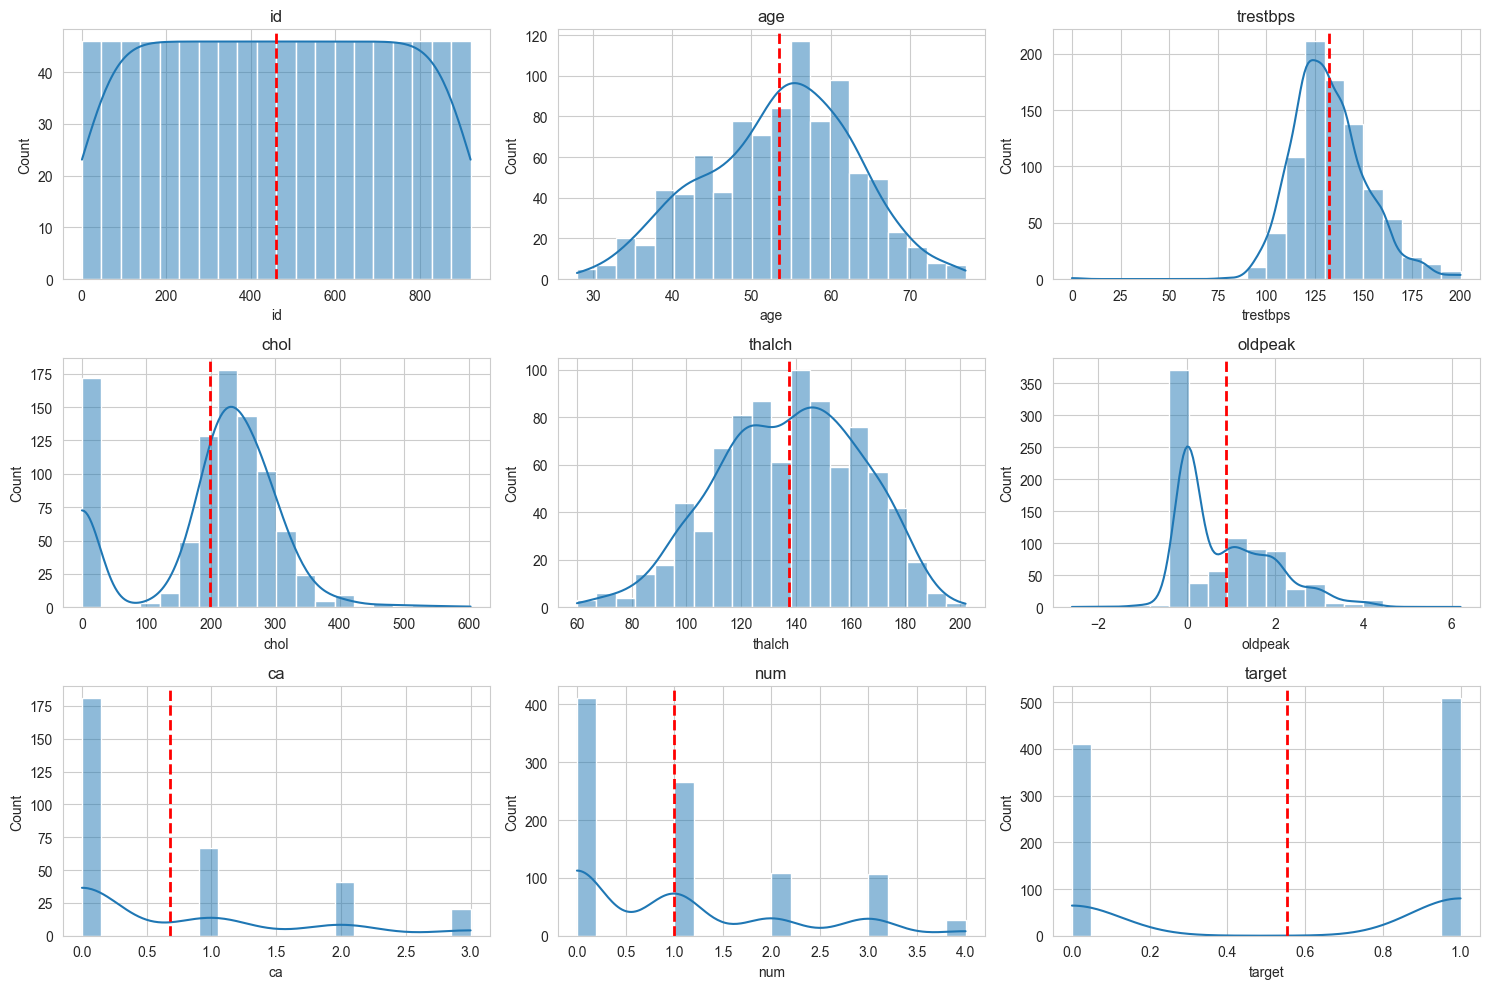

In [90]:
# Histograms for Numerical features
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=20, kde=True)
    plt.axvline(df[col].mean(), color= 'red', linestyle='--', linewidth=2, label='Mean')
    plt.title(col)

plt.tight_layout()
plt.show()


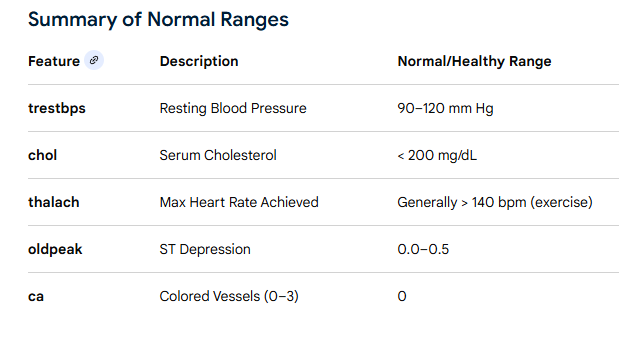

### EDA Notes

- `age` is centered around the mid-50s, which suggests the dataset mainly represents middle-aged and older adults, a medically plausible higher-risk group for heart disease.
- `trestbps` clusters around **120 to 140**, but the presence of zero values is a strong sign of invalid data rather than true patient physiology.
- `chol` is widely spread and right-skewed, with very high values and some impossible zeros. Medically, high cholesterol can matter, but the raw zeros should be cleaned before strong interpretation.
- `thalch` is spread across a wide range, and lower maximum heart rate is clinically meaningful because reduced exercise tolerance can reflect underlying cardiac limitation.
- `oldpeak` is right-skewed, with many low values and a tail toward higher ST depression. Higher values may indicate ischemia, so this feature likely has real medical value.
- `ca` is concentrated near zero but has heavy missingness, so interpretation should stay cautious until cleaning is complete.


## 8. Boxplots for Outlier Check

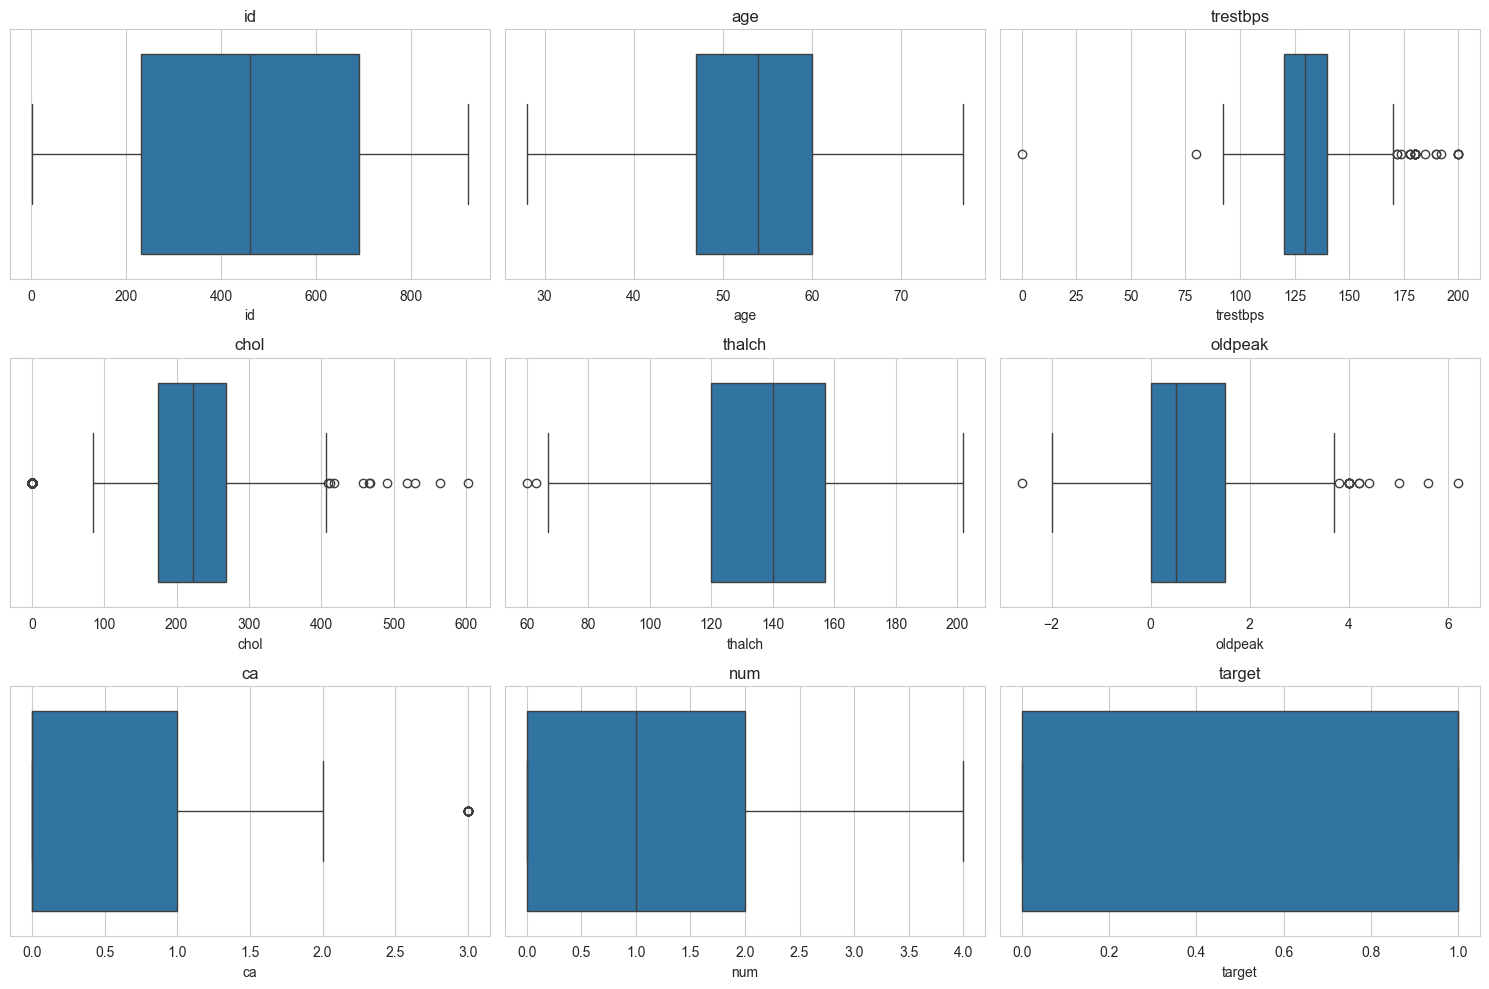

In [91]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### EDA Notes

- The boxplots suggest possible outliers in `trestbps`, `chol`, `oldpeak`, and `ca`.
- Some extreme values may represent real clinical variation, especially for blood pressure, cholesterol, and ST depression, so they should not be removed blindly.
- However, values like `trestbps = 0` and `chol = 0` are medically unrealistic and should be treated as invalid, then imputed later.
- In medical prediction, keeping plausible severe cases is usually better than aggressive outlier removal, because those cases may be exactly the patients we most need the model to detect.
- A sensible next step is to correct impossible values, keep plausible extremes, and let robust models handle the remaining spread.


## 9. Countplots for Categorical Features

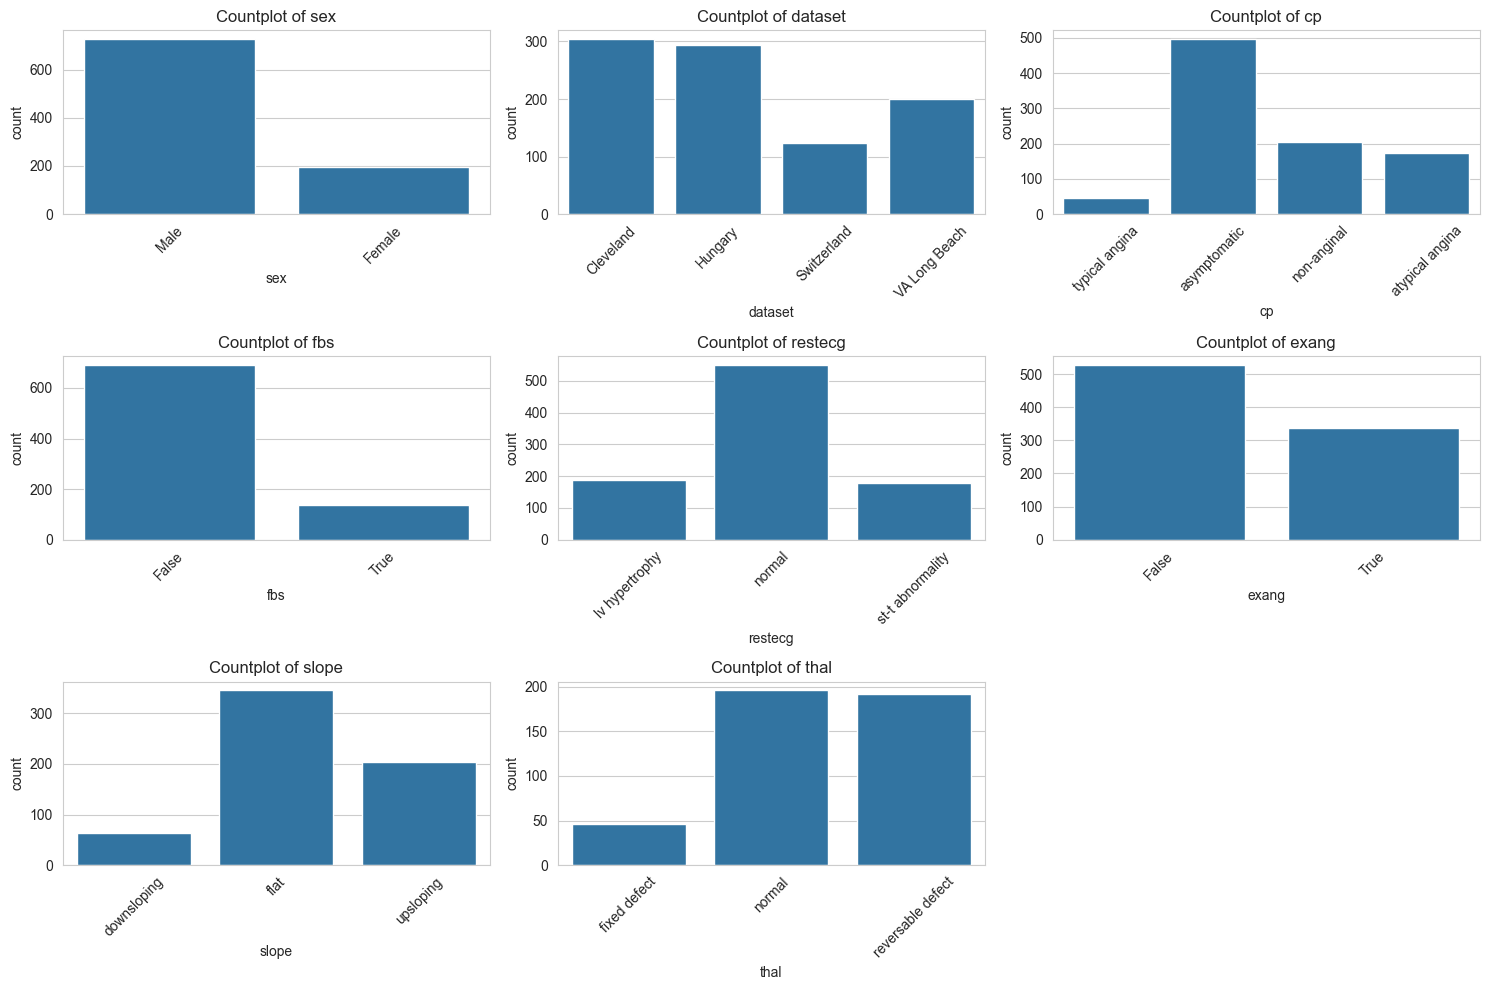

In [95]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3,3,i)
    sns.countplot(data=df, x=col)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### EDA Notes

- The categorical plots are likely to show strong signals in `cp`, `exang`, `slope`, `thal`, `sex`, and `dataset`. These variables are either clinically meaningful or may capture population differences.
- Disease rates are much higher among patients with **asymptomatic chest pain**, **exercise-induced angina**, **flat or downsloping ST slope**, and **abnormal thal results**. These patterns are medically plausible and should matter during modeling.
- The disease rate is also much higher in males than females in this dataset, but this should be interpreted carefully because the sample is not balanced by sex.
- `dataset` shows different disease rates across source hospitals, which may reflect real population differences, collection differences, or dataset bias. It is informative, but it should be used cautiously.


## 10. Correlation Heatmap

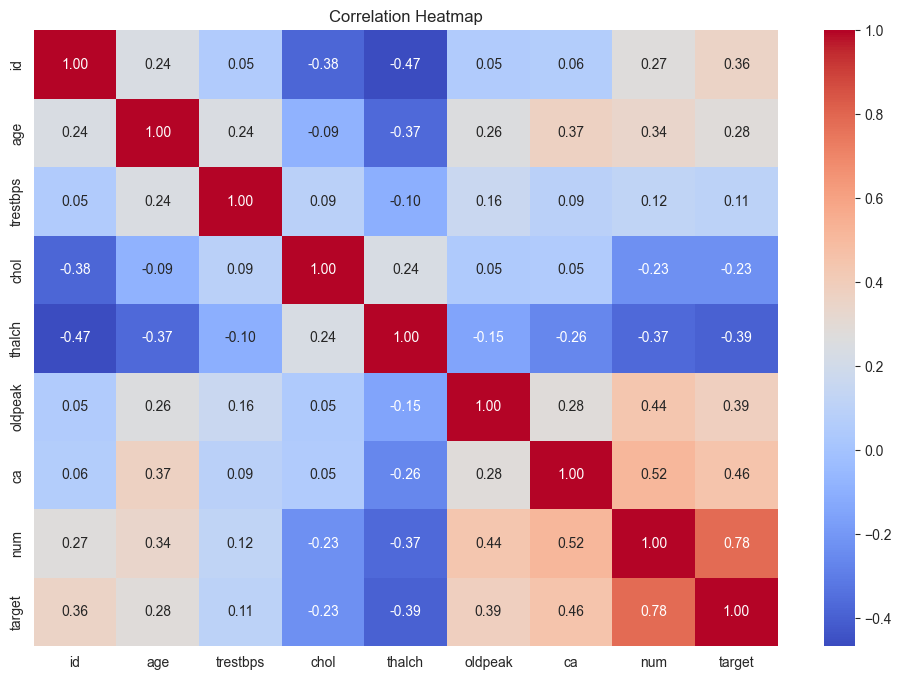

In [98]:
plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### EDA Notes

- The strongest positive numeric relationships with the binary target are `ca` (**0.46**) and `oldpeak` (**0.39**). This makes medical sense because more diseased vessels and stronger ST depression often indicate worse coronary disease.
- `age` has a moderate positive relationship with the target (**0.28**), which is clinically reasonable because heart disease risk tends to rise with age.
- `thalch` has a notable negative relationship with the target (**-0.40**). This suggests patients with lower maximum heart rate are more likely to have disease, which fits reduced exercise capacity as a warning sign.
- `chol` shows a negative correlation (**-0.23**), but this should be treated cautiously because the dataset contains suspicious zero values and combines multiple data sources.
- `id` also correlates with the target, but that is not medically meaningful. It likely reflects data ordering or source effects, so it should be dropped before modeling.


# Final EDA Summary

### Final EDA Summary

- Overall, this is a mixed-type heart disease dataset with **920 patients**, a slightly disease-heavy binary target, and several clinically meaningful predictors.
- The most promising features appear to be `cp`, `exang`, `oldpeak`, `slope`, `ca`, `thalch`, `thal`, `age`, and possibly `dataset`.
- The biggest cleaning priorities for Step 4 are handling large missingness in `ca`, `thal`, and `slope`, imputing the remaining missing values, converting impossible values such as `trestbps = 0` and `chol = 0` into missing values, and dropping `id` from modeling.
- Medically, the dataset makes sense: symptoms during exercise, stress-test abnormalities, vessel involvement, and age all align with known cardiovascular risk patterns.
- Recall remains the key metric because the practical danger is a **false negative**: predicting that a patient is healthy when the patient actually has heart disease.
- The EDA supports starting with an interpretable baseline such as Logistic Regression, then comparing it with stronger nonlinear models while still optimizing for recall and clinical usefulness.
